# Task 1: NDVI Time Series Analysis by Crop Type
**CropSmart / Bitcamp Hackathon — Agricultural Resilience**

This notebook extracts and compares NDVI phenological curves for **corn** and **soybean** pixels
over Iowa during the 2022 growing season, using:
- MODIS MOD13Q1 NDVI (250m, 16-day composites) from NASA AppEEARS
- USDA NASS Cropland Data Layer (CDL, 30m) from CropScape

**CDL crop codes:** Corn = 1, Soybean = 5

> *Note: Portions of this notebook were developed with AI assistance (Claude by Anthropic).*

In [ ]:
# ── Cell 1: Mount Google Drive and install dependencies ──────────────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio scipy matplotlib numpy requests -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import os
import re
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from scipy.ndimage import zoom
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


In [ ]:
# ── Cell 3: Define paths ──────────────────────────────────────────────────────
BASE_DIR  = '/content/drive/MyDrive/bitcamp'
NDVI_DIR  = os.path.join(BASE_DIR, 'ndvi')
CDL_DIR   = os.path.join(BASE_DIR, 'cdl')
OUT_DIR   = os.path.join(BASE_DIR, 'outputs')

os.makedirs(CDL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Iowa bounding box (minX, minY, maxX, maxY) in WGS84
IOWA_BBOX = (-96.6, 40.4, -90.1, 43.5)

# CDL crop codes
CORN_CODE    = 1
SOYBEAN_CODE = 5

print('Paths configured.')

Paths configured.


In [ ]:
# ── Cell 4: Download CDL 2022 for Iowa from CropScape ────────────────────────
# CropScape expects bounding box in EPSG:5070 (Albers Equal Area CONUS)
# Iowa approx bounds in EPSG:5070:

import requests
import re
import os

def download_cdl(year, save_dir):
    save_path = os.path.join(save_dir, f'cdl_{year}_iowa.tif')
    if os.path.exists(save_path) and os.path.getsize(save_path) > 1e5:
        print(f'CDL {year} already downloaded.')
        return save_path

    # Iowa bounding box in EPSG:5070 (Albers Equal Area CONUS)
    # These are the correct native coordinates for CropScape
    minx, miny, maxx, maxy = 23002, 1534556, 710000, 2099652

    api_url = (
        'https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile'
        f'?year={year}&bbox={minx},{miny},{maxx},{maxy}'
    )
    print(f'Requesting CDL {year} ...')
    r = requests.get(api_url, timeout=60)

    # Don't raise_for_status — instead check content
    print(f'  Response status: {r.status_code}')
    print(f'  Response preview: {r.text[:400]}')

    match = re.search(r'<returnURL>(.*?)</returnURL>', r.text)
    if not match:
        match = re.search(r'<r>(.*?)</r>', r.text)
    if not match:
        raise ValueError(f'Could not parse download URL. Full response:\n{r.text}')

    tif_url = match.group(1).strip()
    print(f'  Downloading TIF from: {tif_url}')

    tif_r = requests.get(tif_url, timeout=300, stream=True)
    tif_r.raise_for_status()
    with open(save_path, 'wb') as f:
        for chunk in tif_r.iter_content(chunk_size=65536):
            f.write(chunk)

    print(f'  Saved ({os.path.getsize(save_path)/1e6:.1f} MB) → {save_path}')
    return save_path

cdl_2022_path = download_cdl(2022, CDL_DIR)

CDL 2022 already downloaded.


In [ ]:
# ── Cell 5: Load and inspect CDL 2022 ────────────────────────────────────────
with rasterio.open(cdl_2022_path) as src:
    cdl_data    = src.read(1)
    cdl_crs     = src.crs
    cdl_transform = src.transform
    cdl_shape   = src.shape
    cdl_bounds  = src.bounds

corn_px    = np.sum(cdl_data == CORN_CODE)
soy_px     = np.sum(cdl_data == SOYBEAN_CODE)
total_px   = cdl_data.size

print(f'CDL shape   : {cdl_shape}')
print(f'CDL CRS     : {cdl_crs}')
print(f'Corn pixels : {corn_px:,}  ({100*corn_px/total_px:.1f}%)')
print(f'Soy pixels  : {soy_px:,}  ({100*soy_px/total_px:.1f}%)')

CDL shape   : (18837, 22901)
CDL CRS     : EPSG:5070
Corn pixels : 78,017,455  (18.1%)
Soy pixels  : 90,032,346  (20.9%)


In [ ]:
# ── Cell 6: Load all 2022 NDVI GeoTIFFs ──────────────────────────────────────
# Files downloaded from NASA AppEEARS; named with day-of-year (doy)

def parse_doy(filename):
    """Extract day-of-year from AppEEARS MODIS filename."""
    m = re.search(r'doy(\d{4})(\d{3})', filename)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

ndvi_files = sorted([
    f for f in os.listdir(NDVI_DIR)
    if f.endswith('.tif') and 'NDVI' in f
])

# Keep only 2022 files
ndvi_2022 = [(f, parse_doy(f)) for f in ndvi_files]
ndvi_2022 = [(f, yr, doy) for f, (yr, doy) in ndvi_2022 if yr == 2022]
ndvi_2022.sort(key=lambda x: x[2])  # sort by DOY

print(f'Found {len(ndvi_2022)} NDVI composites for 2022')
print(f'DOY range: {ndvi_2022[0][2]} → {ndvi_2022[-1][2]}')

# Load first file to get NDVI metadata
with rasterio.open(os.path.join(NDVI_DIR, ndvi_2022[0][0])) as src:
    ndvi_crs       = src.crs
    ndvi_transform = src.transform
    ndvi_shape     = src.shape
    ndvi_bounds    = src.bounds

print(f'NDVI shape : {ndvi_shape}')
print(f'NDVI CRS   : {ndvi_crs}')

Found 23 NDVI composites for 2022
DOY range: 1 → 353
NDVI shape : (1489, 3121)
NDVI CRS   : EPSG:4326


In [ ]:
# ── Cell 7: Reproject CDL mask to NDVI grid ───────────────────────────────────
# CDL is 30m Albers; NDVI is 250m Geographic. We reproject CDL to match NDVI.

from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.transform import from_bounds
import rasterio.crs

with rasterio.open(os.path.join(NDVI_DIR, ndvi_2022[0][0])) as ndvi_src:
    ndvi_profile = ndvi_src.profile

# Reproject CDL to NDVI CRS and shape using nearest-neighbour (preserve class labels)
cdl_reprojected = np.zeros(ndvi_shape, dtype=np.uint8)

with rasterio.open(cdl_2022_path) as cdl_src:
    reproject(
        source=rasterio.band(cdl_src, 1),
        destination=cdl_reprojected,
        src_transform=cdl_src.transform,
        src_crs=cdl_src.crs,
        dst_transform=ndvi_transform,
        dst_crs=ndvi_crs,
        resampling=Resampling.nearest
    )

corn_mask = (cdl_reprojected == CORN_CODE)
soy_mask  = (cdl_reprojected == SOYBEAN_CODE)

print(f'Reprojected CDL shape : {cdl_reprojected.shape}')
print(f'Corn pixels in NDVI grid : {corn_mask.sum():,}')
print(f'Soy pixels in NDVI grid  : {soy_mask.sum():,}')

Reprojected CDL shape : (1489, 3121)
Corn pixels in NDVI grid : 498,941
Soy pixels in NDVI grid  : 466,950


In [ ]:
# ── Cell 8: Extract mean/Q25/Q75 NDVI per crop type per date ─────────────────

NDVI_SCALE    = 0.0001   # MODIS NDVI scale factor
NDVI_FILL     = -28672   # MODIS fill value

records = []  # list of (date, corn_mean, corn_q25, corn_q75, soy_mean, soy_q25, soy_q75)

for fname, yr, doy in ndvi_2022:
    date = datetime.strptime(f'2022 {doy}', '%Y %j')
    path = os.path.join(NDVI_DIR, fname)

    with rasterio.open(path) as src:
        raw = src.read(1).astype(float)

    # Apply scale and mask fill/invalid
    ndvi = np.where(raw == NDVI_FILL, np.nan, raw * NDVI_SCALE)
    ndvi = np.where((ndvi < -1) | (ndvi > 1), np.nan, ndvi)

    def stats(mask):
        vals = ndvi[mask]
        vals = vals[~np.isnan(vals)]
        if len(vals) < 10:
            return np.nan, np.nan, np.nan
        return np.mean(vals), np.percentile(vals, 25), np.percentile(vals, 75)

    c_mean, c_q25, c_q75 = stats(corn_mask)
    s_mean, s_q25, s_q75 = stats(soy_mask)
    records.append((date, c_mean, c_q25, c_q75, s_mean, s_q25, s_q75))

dates      = [r[0] for r in records]
corn_mean  = np.array([r[1] for r in records])
corn_q25   = np.array([r[2] for r in records])
corn_q75   = np.array([r[3] for r in records])
soy_mean   = np.array([r[4] for r in records])
soy_q25    = np.array([r[5] for r in records])
soy_q75    = np.array([r[6] for r in records])

print('NDVI extraction complete.')
print(f'Peak corn NDVI: {np.nanmax(corn_mean):.3f}')
print(f'Peak soy NDVI : {np.nanmax(soy_mean):.3f}')

NDVI extraction complete.
Peak corn NDVI: 0.874
Peak soy NDVI : 0.867


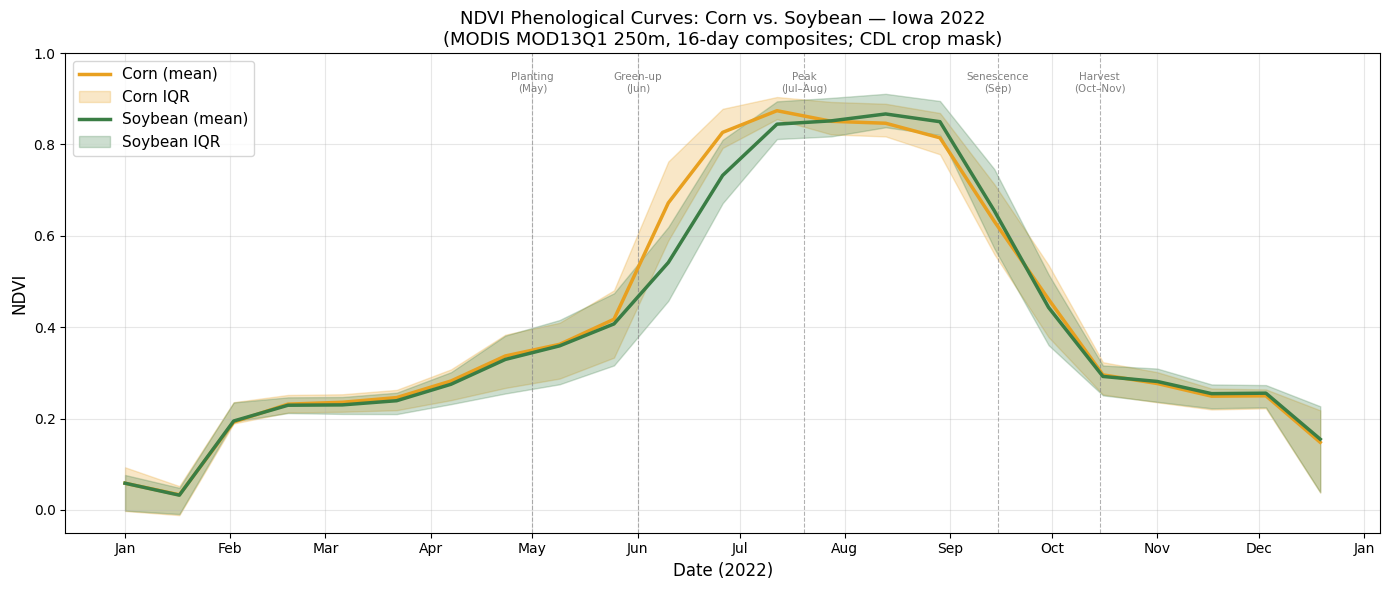

Saved to /content/drive/MyDrive/bitcamp/outputs/task1_ndvi_phenology.png


In [ ]:
# ── Cell 9: Plot phenological curves ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))

# Corn
ax.plot(dates, corn_mean, color='#E8A020', linewidth=2.5, label='Corn (mean)', zorder=3)
ax.fill_between(dates, corn_q25, corn_q75, alpha=0.25, color='#E8A020', label='Corn IQR')

# Soybean
ax.plot(dates, soy_mean, color='#3A7D44', linewidth=2.5, label='Soybean (mean)', zorder=3)
ax.fill_between(dates, soy_q25, soy_q75, alpha=0.25, color='#3A7D44', label='Soybean IQR')

# Annotate phenological stages (approximate for Iowa)
stages = {
    'Planting\n(May)':    datetime(2022, 5, 1),
    'Green-up\n(Jun)':    datetime(2022, 6, 1),
    'Peak\n(Jul–Aug)':    datetime(2022, 7, 20),
    'Senescence\n(Sep)':  datetime(2022, 9, 15),
    'Harvest\n(Oct–Nov)': datetime(2022, 10, 15),
}
for label, dt in stages.items():
    ax.axvline(dt, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(dt, 0.92, label, fontsize=7.5, ha='center', color='gray',
            transform=ax.get_xaxis_transform())

ax.set_xlabel('Date (2022)', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('NDVI Phenological Curves: Corn vs. Soybean — Iowa 2022\n'
             '(MODIS MOD13Q1 250m, 16-day composites; CDL crop mask)', fontsize=13)
ax.set_ylim(-0.05, 1.0)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(OUT_DIR, 'task1_ndvi_phenology.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

In [ ]:
# ── Cell 10: Summary statistics table ────────────────────────────────────────
import pandas as pd

df = pd.DataFrame({
    'Date': dates,
    'Corn_Mean': corn_mean,
    'Corn_Q25':  corn_q25,
    'Corn_Q75':  corn_q75,
    'Soy_Mean':  soy_mean,
    'Soy_Q25':   soy_q25,
    'Soy_Q75':   soy_q75,
})
df['Date'] = pd.to_datetime(df['Date'])

# Growing season only (May–October)
gs = df[(df['Date'].dt.month >= 5) & (df['Date'].dt.month <= 10)]

print('=== Growing Season Summary (May–Oct 2022) ===')
print(f"Corn  — Peak NDVI: {gs['Corn_Mean'].max():.3f}  "
      f"(Date: {gs.loc[gs['Corn_Mean'].idxmax(), 'Date'].strftime('%b %d')})")
print(f"Soy   — Peak NDVI: {gs['Soy_Mean'].max():.3f}  "
      f"(Date: {gs.loc[gs['Soy_Mean'].idxmax(), 'Date'].strftime('%b %d')})")

csv_path = os.path.join(OUT_DIR, 'task1_ndvi_stats.csv')
df.to_csv(csv_path, index=False)
print(f'\nFull stats saved to {csv_path}')
gs.round(4)

=== Growing Season Summary (May–Oct 2022) ===
Corn  — Peak NDVI: 0.874  (Date: Jul 12)
Soy   — Peak NDVI: 0.867  (Date: Aug 13)

Full stats saved to /content/drive/MyDrive/bitcamp/outputs/task1_ndvi_stats.csv


,Date,Corn_Mean,Corn_Q25,Corn_Q75,Soy_Mean,Soy_Q25,Soy_Q75
8,2022-05-09,0.3625,0.2875,0.4097,0.3592,0.2750,0.4157
9,2022-05-25,0.4174,0.3333,0.4806,0.4071,0.3163,0.4742
10,2022-06-10,0.6721,0.5898,0.7626,0.5416,0.4577,0.6193
11,2022-06-26,0.8265,0.7924,0.8781,0.7323,0.6713,0.8102
12,2022-07-12,0.8739,0.8555,0.9039,0.8445,0.8119,0.8944
13,2022-07-28,0.8508,0.8220,0.8931,0.8518,0.8177,0.9020
14,2022-08-13,0.8465,0.8176,0.8891,0.8668,0.8377,0.9109
15,2022-08-29,0.8146,0.7785,0.8689,0.8499,0.8209,0.8952
16,2022-09-14,0.6319,0.5600,0.7130,0.6550,0.5726,0.7462
17,2022-09-30,0.4610,0.3780,0.5359,0.4431,0.3605,0.5153


## Interpretation

**Corn** shows a rapid green-up in late May/June and reaches peak NDVI in mid-July (~0.85),
reflecting its C4 photosynthetic pathway and dense canopy. Senescence is steep from late August
into September as dough and dent stages advance.

**Soybean** green-up lags corn by ~2–3 weeks (June planting), peaks slightly later in August
at a marginally lower NDVI (~0.80), and senesces more gradually through October.

The IQR bands show that corn is more spatially consistent (narrower band) while soybean
exhibits higher within-class variability — likely driven by variety differences and planting
date variation across the large Iowa study area.

Key distinguishing phenological features:
1. Timing of green-up onset (corn earlier by ~2 weeks)
2. Peak NDVI date (corn peaks ~2–3 weeks before soybean)
3. Senescence rate (corn drops more steeply post-peak)

In [ ]:
# ── Cell 11: Build NDVI-based feature matrix for crop classification ──────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import numpy as np

# We already have:
# - ndvi_stack: (46, H, W) NDVI arrays for 2022
# - corn_mask, soy_mask: boolean masks on NDVI grid
# - dates: list of datetimes for each composite

# --- Create ndvi_stack from individual files ---
# This was missing and caused the NameError
ndvi_stack_list = []
for fname, yr, doy in ndvi_2022:
    path = os.path.join(NDVI_DIR, fname)
    with rasterio.open(path) as src:
        raw = src.read(1).astype(float)
    # Apply scale and mask fill/invalid
    ndvi = np.where(raw == NDVI_FILL, np.nan, raw * NDVI_SCALE)
    ndvi = np.where((ndvi < -1) | (ndvi > 1), np.nan, ndvi)
    ndvi_stack_list.append(ndvi)

ndvi_stack = np.array(ndvi_stack_list)
print(f'ndvi_stack created with shape: {ndvi_stack.shape}')
# ------------------------------------------------

# Extract NDVI at key phenological windows
# Find indices closest to target DOYs
import datetime

def get_doy_index(target_doy):
    """Find index in ndvi_stack closest to target day of year."""
    doys = [d.timetuple().tm_yday for d in dates]
    return min(range(len(doys)), key=lambda i: abs(doys[i] - target_doy))

# Key DOY targets
idx_early    = get_doy_index(120)   # late April — pre green-up
idx_greenup  = get_doy_index(160)   # early June — green-up
idx_mid      = get_doy_index(193)   # mid July — approaching peak
idx_peak     = get_doy_index(220)   # early August — peak
idx_late     = get_doy_index(260)   # mid September — senescence
idx_harvest  = get_doy_index(300)   # late October — post harvest

print('DOY windows selected:')
for name, idx in [('Early(120)', idx_early), ('Green-up(160)', idx_greenup),
                   ('Mid(193)', idx_mid), ('Peak(220)', idx_peak),
                   ('Late(260)', idx_late), ('Harvest(300)', idx_harvest)]:
    actual_doy = dates[idx].timetuple().tm_yday
    print(f'  {name}: using composite DOY {actual_doy}')

# Load NDVI values at each window
def get_ndvi_at(idx):
    # Now we can directly use ndvi_stack
    return ndvi_stack[idx]

ndvi_early   = get_ndvi_at(idx_early)
ndvi_greenup = get_ndvi_at(idx_greenup)
ndvi_mid     = get_ndvi_at(idx_mid)
ndvi_peak    = get_ndvi_at(idx_peak)
ndvi_late    = get_ndvi_at(idx_late)
ndvi_harvest = get_ndvi_at(idx_harvest)

# Compute peak NDVI and peak DOY per pixel from full stack
peak_ndvi = np.nanmax(ndvi_stack, axis=0)
peak_doy  = np.array([dates[i].timetuple().tm_yday for i in range(len(dates))])
peak_doy_map = peak_doy[np.nanargmax(ndvi_stack, axis=0)]

# Greenup rate: slope from early to greenup window
greenup_rate = (ndvi_greenup - ndvi_early) / (160 - 120 + 1e-6)

# Senescence rate: slope from peak to late window
senescence_rate = (ndvi_late - ndvi_peak) / (260 - 220 + 1e-6)

print('\nFeature arrays computed.')

ndvi_stack created with shape: (23, 1489, 3121)
DOY windows selected:
  Early(120): using composite DOY 113
  Green-up(160): using composite DOY 161
  Mid(193): using composite DOY 193
  Peak(220): using composite DOY 225
  Late(260): using composite DOY 257
  Harvest(300): using composite DOY 305

Feature arrays computed.


In [ ]:
# ── Cell 12: Assemble feature matrix and labels ───────────────────────────────

# Combined mask: pixels that are corn OR soy and have valid NDVI
valid = (corn_mask | soy_mask)

# Stack all features
feature_arrays = [
    ndvi_early, ndvi_greenup, ndvi_mid,
    ndvi_peak, ndvi_late, ndvi_harvest,
    peak_ndvi, peak_doy_map.astype(float),
    greenup_rate, senescence_rate
]
feature_names_t1 = [
    'ndvi_early', 'ndvi_greenup', 'ndvi_mid',
    'ndvi_peak', 'ndvi_late', 'ndvi_harvest',
    'peak_ndvi', 'peak_doy',
    'greenup_rate', 'senescence_rate'
]

# Build matrix — only valid pixels with no NaN features
X_raw = np.stack([arr[valid] for arr in feature_arrays], axis=1)
y_raw = np.where(corn_mask[valid], CORN_CODE, SOYBEAN_CODE)

# Remove rows with any NaN
nan_rows = np.any(np.isnan(X_raw), axis=1)
X_clean  = X_raw[~nan_rows]
y_clean  = y_raw[~nan_rows]

print(f'Feature matrix : {X_clean.shape}')
print(f'Corn pixels    : {np.sum(y_clean == CORN_CODE):,}')
print(f'Soybean pixels : {np.sum(y_clean == SOYBEAN_CODE):,}')

Feature matrix : (965891, 10)
Corn pixels    : 498,941
Soybean pixels : 466,950


In [ ]:
# ── Cell 13: Train and evaluate NDVI-based classifier ────────────────────────

# Subsample for speed
np.random.seed(42)
n_sample = min(300_000, len(y_clean))
idx = np.random.choice(len(y_clean), n_sample, replace=False)
X_s, y_s = X_clean[idx], y_clean[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=y_s
)

print(f'Training: {len(X_train):,}  |  Test: {len(X_test):,}')

rf_ndvi = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)
rf_ndvi.fit(X_train, y_train)
y_pred_ndvi = rf_ndvi.predict(X_test)

print('\n=== NDVI-based Classification Report ===')
print(classification_report(
    y_test, y_pred_ndvi,
    target_names=['Corn', 'Soybean'],
    labels=[CORN_CODE, SOYBEAN_CODE]
))

Training: 240,000  |  Test: 60,000

=== NDVI-based Classification Report ===
              precision    recall  f1-score   support

        Corn       0.79      0.79      0.79     30967
     Soybean       0.77      0.78      0.78     29033

    accuracy                           0.78     60000
   macro avg       0.78      0.78      0.78     60000
weighted avg       0.78      0.78      0.78     60000



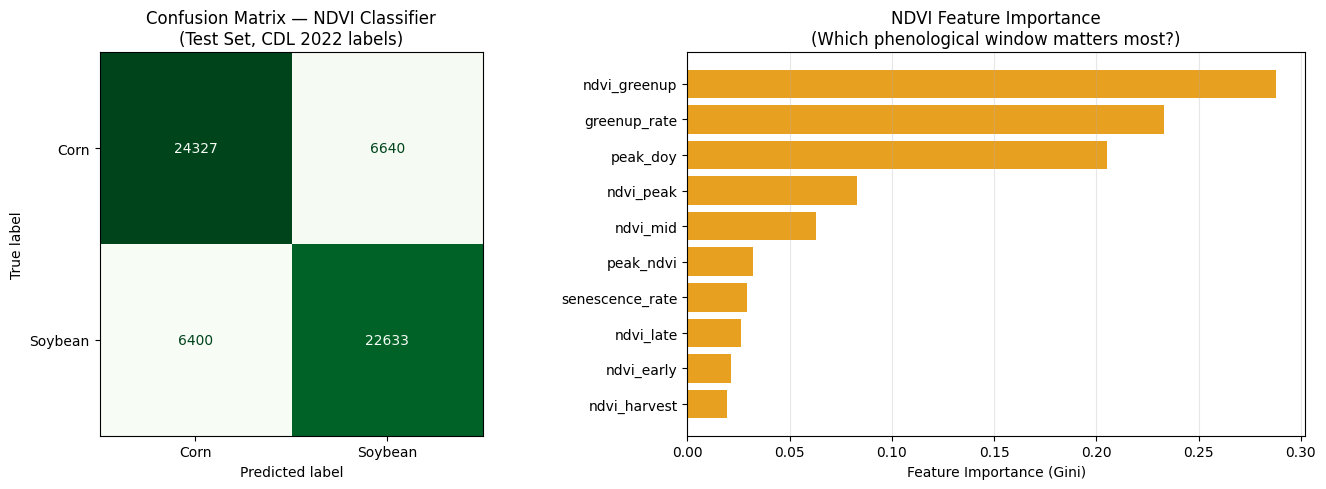

Saved → /content/drive/MyDrive/bitcamp/outputs/task1_ndvi_classifier.png


In [ ]:
# ── Cell 14: Confusion matrix + feature importance ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_ndvi, labels=[CORN_CODE, SOYBEAN_CODE])
disp = ConfusionMatrixDisplay(cm, display_labels=['Corn', 'Soybean'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — NDVI Classifier\n(Test Set, CDL 2022 labels)', fontsize=12)

importances = rf_ndvi.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
axes[1].barh(
    [feature_names_t1[i] for i in sorted_idx],
    importances[sorted_idx],
    color='#E8A020'
)
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('NDVI Feature Importance\n(Which phenological window matters most?)', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
out_path = os.path.join(OUT_DIR, 'task1_ndvi_classifier.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')